In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
import os
from tensorflow.keras.models import load_model

In [2]:
print("1. Memuat Dataset dan Model...")

# Menangani path agar aman dijalankan di Jupyter Notebook maupun Terminal
try:
    # Jika dijalankan via terminal (.py)
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Jika dijalankan langsung di cell Jupyter Notebook (.ipynb)
    BASE_DIR = os.getcwd()

path_data = os.path.join(BASE_DIR, 'data', 'testing', 'data_testing_v2.csv')
path_scaler = os.path.join(BASE_DIR, 'models', 'scaler.pkl')
path_xgb = os.path.join(BASE_DIR, 'models', 'xgb_model4.pkl')
path_gru = os.path.join(BASE_DIR, 'models', 'gru_model4.keras')

1. Memuat Dataset dan Model...


In [3]:
# 1. Load Data Testing Asli
df = pd.read_csv(path_data)
fitur_x = [
    'ph', 'tds', 'turbidity', 'temperature',
    'turbidity_MA_3', 'tds_MA_3', 'ph_MA_3',
    'turbidity_Diff', 'tds_Diff', 'ph_Diff',
    'turbidity_Std_3', 'tds_Std_3'
]

In [4]:
# 2. Load Scaler & Model
try:
    with open(path_scaler, 'rb') as file:
        scaler = pickle.load(file)
    model_xgb = joblib.load(path_xgb)
    model_gru = load_model(path_gru)
except Exception as e:
    print(f"Error memuat file: {e}")
    raise e

print("2. Melakukan Prediksi Simulasi EWS...")

2. Melakukan Prediksi Simulasi EWS...


3. Membuat Visualisasi Laporan...
Selesai! Gambar berhasil disimpan dengan nama: 'simulasi_real_inference_v2.png'


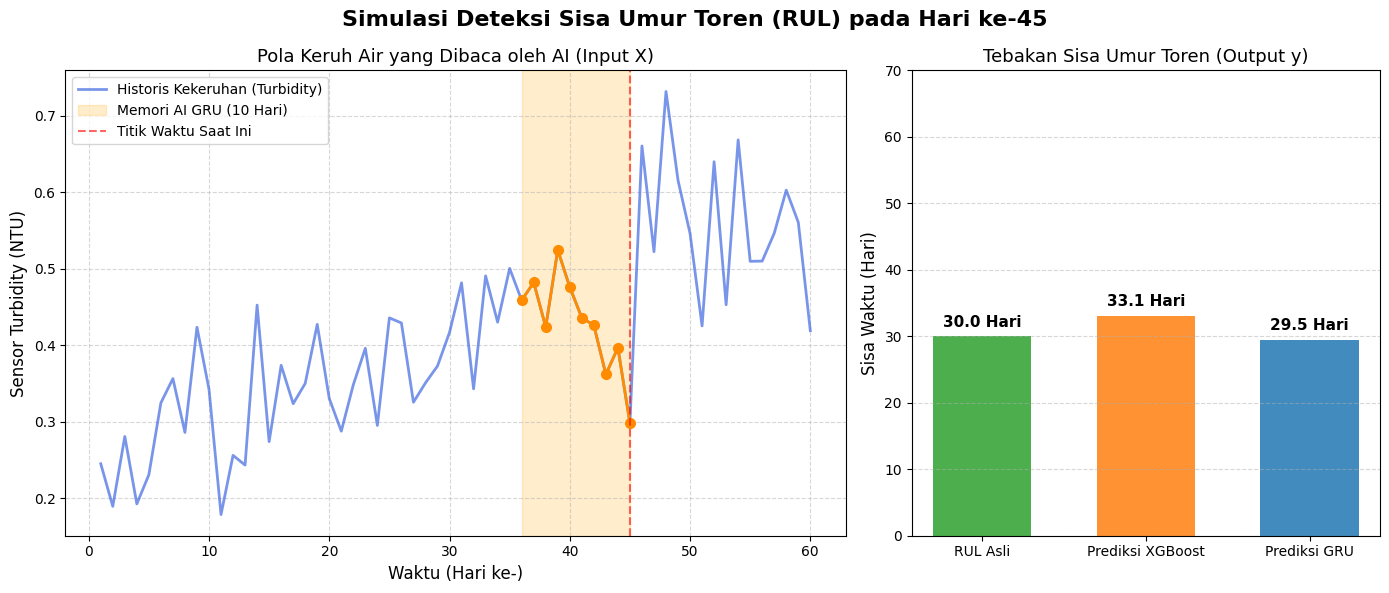

In [7]:
# ==========================================
# SETUP SIMULASI HARI INI
# ==========================================
hari_sekarang = 45 

# UPDATE 3: Window size GRU yang baru adalah 10 hari
window_size = 10

idx_akhir = hari_sekarang 
idx_awal = hari_sekarang - window_size 

# Ekstrak data mentah dari DataFrame
X_gru_raw = df.iloc[idx_awal:idx_akhir][fitur_x].values
X_xgb_raw = df.iloc[idx_akhir-1:idx_akhir][fitur_x].values

# NORMALISASI TUNGGAL (Menggunakan skala memori AI)
# X_gru_scaled = scaler.transform(X_gru_raw)
# X_xgb_scaled = scaler.transform(X_xgb_raw)

# Sesuaikan bentuk array untuk GRU (1 sampel, 10 hari, 12 fitur)
# X_gru_3d = X_gru_scaled.reshape((1, window_size, len(fitur_x)))

# Prediksi
# pred_gru = model_gru.predict(X_gru_3d, verbose=0)[0][0]
# pred_xgb = model_xgb.predict(X_xgb_scaled)[0]

# Sesuaikan bentuk array untuk GRU langsung dari X_gru_raw
X_gru_3d = X_gru_raw.reshape((1, window_size, len(fitur_x)))

# Prediksi langsung tanpa lewat scaler.transform()
pred_gru = model_gru.predict(X_gru_3d, verbose=0)[0][0]
pred_xgb = model_xgb.predict(X_xgb_raw)[0]

# RUL Asli juga dipotong maksimal 60 hari agar adil dengan target AI
true_rul = min(df.iloc[idx_akhir-1]['RUL'], 60)

print("3. Membuat Visualisasi Laporan...")

# ==========================================
# MENGGAMBAR VISUALISASI 2 PANEL
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1.2]})
fig.suptitle(f'Simulasi Deteksi Sisa Umur Toren (RUL) pada Hari ke-{hari_sekarang}', fontsize=16, fontweight='bold')

# --- PANEL KIRI: Grafik Sensor ---
batas_tampil = 60
# UPDATE 4: Menggunakan kolom 'turbidity' huruf kecil
ax1.plot(df['Hari'][:batas_tampil], df['turbidity'][:batas_tampil], color='royalblue', linewidth=2, alpha=0.7, label='Historis Kekeruhan (Turbidity)')

hari_window = df['Hari'][idx_awal:idx_akhir]
turbidity_window = df['turbidity'][idx_awal:idx_akhir]

ax1.axvspan(df['Hari'].iloc[idx_awal], df['Hari'].iloc[idx_akhir-1], color='orange', alpha=0.2, label=f'Memori AI GRU ({window_size} Hari)')
ax1.plot(hari_window, turbidity_window, marker='o', color='darkorange', linewidth=2, markersize=7)

ax1.axvline(x=hari_sekarang, color='red', linestyle='--', alpha=0.6, label='Titik Waktu Saat Ini')

ax1.set_xlabel('Waktu (Hari ke-)', fontsize=12)
ax1.set_ylabel('Sensor Turbidity (NTU)', fontsize=12)
ax1.set_title('Pola Keruh Air yang Dibaca oleh AI (Input X)', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# --- PANEL KANAN: Hasil Prediksi ---
kategori = ['RUL Asli', 'Prediksi XGBoost', 'Prediksi GRU']
nilai = [true_rul, pred_xgb, pred_gru]
warna = ['#2ca02c', '#ff7f0e', '#1f77b4'] 

bars = ax2.bar(kategori, nilai, color=warna, alpha=0.85, width=0.6)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f} Hari', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_ylabel('Sisa Waktu (Hari)', fontsize=12)
ax2.set_title('Tebakan Sisa Umur Toren (Output y)', fontsize=13)
ax2.set_ylim(0, 70) 
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Menyimpan gambar
nama_file_gambar = 'simulasi_real_inference_v2.png'
fig.savefig(nama_file_gambar, dpi=300, bbox_inches='tight', facecolor='white')

print(f"Selesai! Gambar berhasil disimpan dengan nama: '{nama_file_gambar}'")
plt.show()